# 教師あり学習 — 回帰タスク
西宮市の中古マンションの取引情報から，住宅価格を推定する．

## データセットの読み込み
- 不動産情報ライブラリ (https://www.reinfolib.mlit.go.jp/) の 不動産価格のページ (https://www.reinfolib.mlit.go.jp/realEstatePrices/) から取得した，西宮市の中古マンション等の取引価格のデータを加工したものを用いる
- 加工の詳細は，下方の「元データ (housing.csv) の生成手順」を参照

**説明変数：**

|変数名|単位|内容|
|-----:|:-:|:---|
|**station**|-|最寄駅|
|**to_station**|分|最寄り駅までの距離|
|**#_of_rooms**|個数|部屋数|
|**floor_plan**|-|間取り|
|**area**|㎡|面積|
|**tx.yr.**|年|取引時期|
|**age**|年数|築年数|
|**bldg.struct.**|-|建物の構造|
|**LUZ**|-|都市計画| 
|**renovation**|-|改装|

**目的変数：**

|変数名|単位|内容|
|-----:|:-:|:---|
|**price**|万円|取引価格（総額）|


In [5]:
# pandas ライブラリをインポートする
import pandas as pd

# データセットの読み込み
df = pd.read_csv("housing25.csv", index_col=0)

# 説明変数 x と目的変数 y を設定
x = df.drop('price', axis=1)
y = df['price']

display(df)
display(df.describe(include='all'))

,station,to_station,#_of_rooms,floor_plan,area,tx.yr.,age,bldg.struct.,LUZ,renovation,price
0,夙川,2.0,3.0,２ＬＤＫ,55.0,2022.0,24.0,ＲＣ,２中住専,未改装,4200.0
1,夙川,3.0,5.0,４ＬＤＫ,85.0,2021.0,23.0,ＲＣ,２中住専,未改装,5800.0
2,夙川,3.0,5.0,４ＬＤＫ,90.0,2020.0,22.0,ＲＣ,２中住専,未改装,6000.0
3,夙川,3.0,4.0,３ＬＤＫ,70.0,2020.0,22.0,ＲＣ,２中住専,改装済み,5400.0
6,西宮(ＪＲ),11.0,4.0,３ＬＤＫ,65.0,2023.0,7.0,ＲＣ,１種住居,未改装,4700.0
...,...,...,...,...,...,...,...,...,...,...,...
6872,武庫川,18.0,4.0,３ＬＤＫ,75.0,2008.0,14.0,ＲＣ,１種住居,未改装,2400.0
6873,夙川,8.0,4.0,３ＬＤＫ,75.0,2008.0,11.0,ＲＣ,１中住専,未改装,4000.0
6874,夙川,7.0,4.0,３ＬＤＫ,70.0,2007.0,10.0,ＲＣ,１中住専,未改装,2600.0
6875,門戸厄神,11.0,4.0,３ＬＤＫ,70.0,2008.0,8.0,ＲＣ,１中住専,未改装,2600.0


,station,to_station,#_of_rooms,floor_plan,area,tx.yr.,age,bldg.struct.,LUZ,renovation,price
count,5610,5610.000000,5610.000000,5610,5610.000000,5610.000000,5610.000000,5610,5610,5610,5610.000000
unique,33,NaN,NaN,18,NaN,NaN,NaN,5,11,2,NaN
top,西宮(阪神),NaN,NaN,３ＬＤＫ,NaN,NaN,NaN,ＲＣ,１中住専,未改装,NaN
freq,627,NaN,NaN,3593,NaN,NaN,NaN,4438,2564,4009,NaN
mean,NaN,10.487879,3.891979,NaN,72.138146,2015.609982,19.118717,NaN,NaN,NaN,2814.177077
std,NaN,6.454494,0.714885,NaN,16.811901,5.173831,11.916981,NaN,NaN,NaN,1371.661435
min,NaN,0.000000,1.000000,NaN,15.000000,2007.000000,0.000000,NaN,NaN,NaN,1.400000
25%,NaN,6.000000,4.000000,NaN,65.000000,2011.000000,10.000000,NaN,NaN,NaN,1800.000000
50%,NaN,9.000000,4.000000,NaN,70.000000,2015.000000,17.000000,NaN,NaN,NaN,2700.000000
75%,NaN,14.000000,4.000000,NaN,80.000000,2020.000000,26.000000,NaN,NaN,NaN,3600.000000


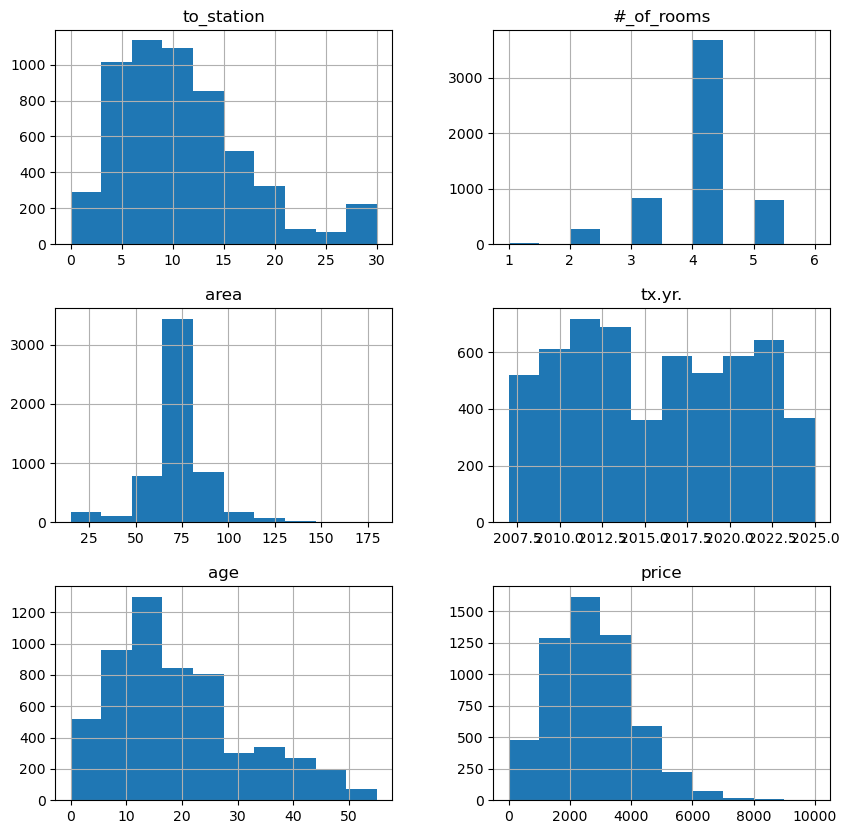

In [6]:
# 各変数のヒストグラム (数量化された列のみ)
import matplotlib.pyplot as plt

# figsize でグラフの大きさを大きくしている
df[['to_station','#_of_rooms','area','tx.yr.','age','price']].hist(figsize=(10, 10))
plt.show()

,to_station,#_of_rooms,area,tx.yr.,age,price
to_station,1.000000,0.148550,0.111728,-0.014108,0.008089,-0.218205
#_of_rooms,0.148550,1.000000,0.639287,-0.036072,-0.116231,0.256559
area,0.111728,0.639287,1.000000,-0.010693,-0.131537,0.481141
tx.yr.,-0.014108,-0.036072,-0.010693,1.000000,0.301057,0.265934
age,0.008089,-0.116231,-0.131537,0.301057,1.000000,-0.492380
price,-0.218205,0.256559,0.481141,0.265934,-0.492380,1.000000


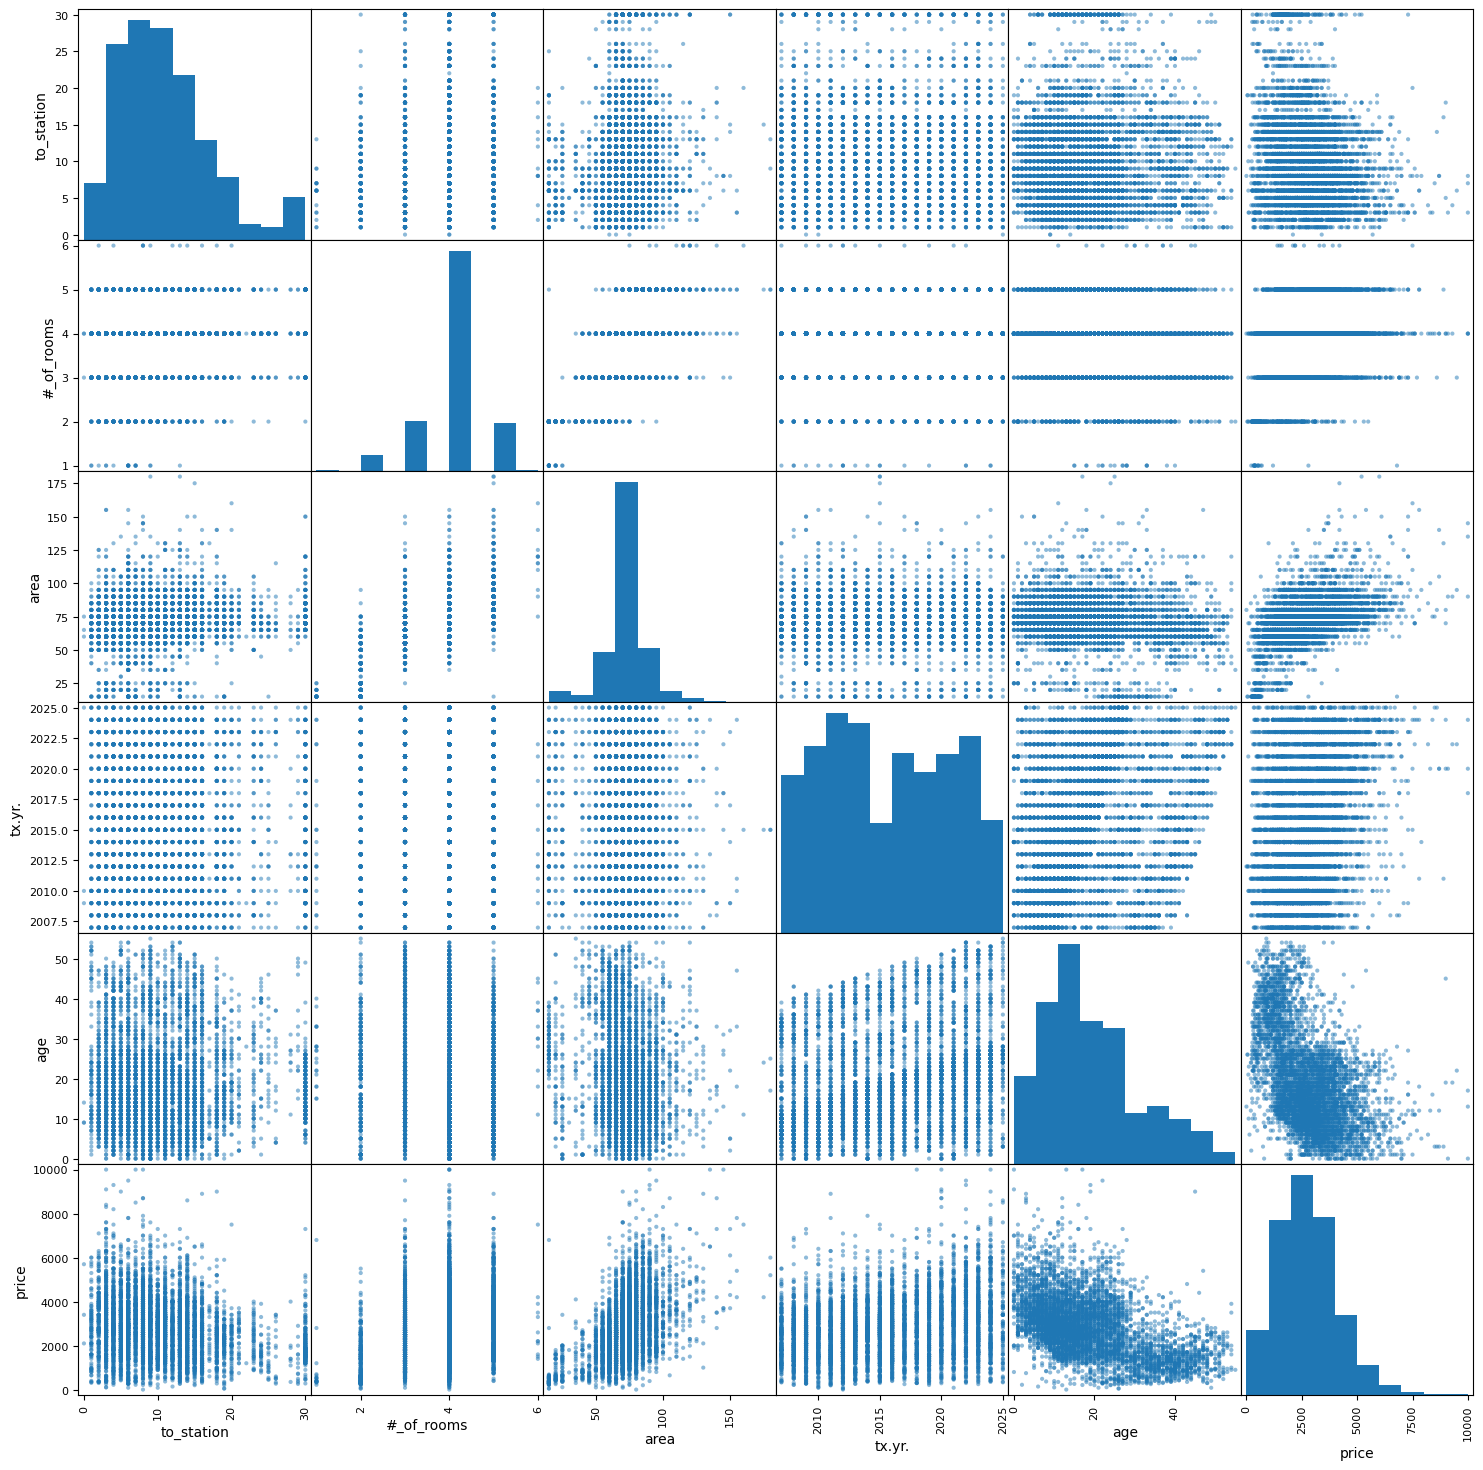

In [7]:
# 相関係数と散布図行列 (数量化された列のみ)

# 相関係数表の表示 — 相関係数が1に近いほど強い正の相関，-1に近いほど強い負の相関，0に近いほど無相関
display(df[['to_station','#_of_rooms','area','tx.yr.','age','price']].corr())

# 散布図行列の表示
from pandas.plotting import scatter_matrix
# figsize でグラフを大きくし，alpha でドットの透明度を上げている
sm = scatter_matrix(df[['to_station','#_of_rooms','area','tx.yr.','age','price']], figsize=(18, 18))

## 準備 — 訓練データとテストデータの分割

<div style="margin-left:4em;">

| 変数      | 内容 |
|:--------- |:---- |
| `x_train` | 訓練データの説明変数 |
| `x_test`  | テストデータの説明変数 |
| `y_train` | 訓練データの目的変数 |
| `y_test`  | テストデータの目的変数 |
</div>

- 訓練データのサイズは全体の70%(0.7)，テストデータのサイズは全体の30%(0.3)


In [8]:
# 学習データとテストデータの分割
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=0)

print(len(x_train), len(x_test))

4207 1403


## 単回帰分析による学習
- `age` だけを説明変数として単回帰分析をしてみる
  $$
  \mathrm{price} = A\cdot\mathrm{age} + B\quad(A: 係数，B: 切片)
  $$
  というモデル

切片 =  3917.8540564922346


,変数名,係数
0,age,-57.399963


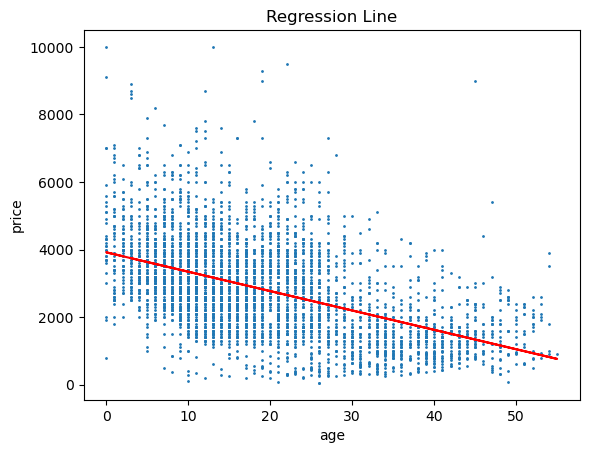

In [9]:
# 単回帰分析 (age) 

# 説明変数を age のみに限定
x_train1 = x_train[['age']]
x_test1 = x_test[['age']]

# LinearRegression (回帰分析) モデルを生成して訓練データを適用
from sklearn.linear_model import LinearRegression
sr1_model = LinearRegression()
sr1_model.fit(x_train1, y_train)

# 結果の表示
print('切片 = ', sr1_model.intercept_)
display(pd.DataFrame({'変数名': x_train1.columns, '係数': sr1_model.coef_}))

# グラフによる可視化
import matplotlib.pyplot as plt

plt.title('Regression Line')    # タイトル
plt.xlabel('age')               # 横軸ラベル
plt.ylabel('price')             # 縦軸ラベル

plt.scatter(x_train1, y_train, s=1)                                 # 散布図(青)
plt.plot(x_train1['age'], sr1_model.predict(x_train1), color='red') # 回帰直線(赤)

plt.show()  # 表示

In [10]:
# 決定係数の表示
# 0 ～ 1 で，1に近いほど良い成績
print('r^2 (訓練データ):   ', sr1_model.score(x_train1, y_train))
print('r^2 (テストデータ): ', sr1_model.score(x_test1, y_test))

# 訓練データとテストデータにおける，
# 観測値と予測値の二乗平均平方根誤差(RMSE; 二乗誤差の平均値の平方根)の表示

# x_train1 と x_test1 に対する予測値
sr1_pred_train = sr1_model.predict(x_train1)
sr1_pred_test = sr1_model.predict(x_test1)

# RMSEの表示
from sklearn.metrics import mean_squared_error
from math import sqrt
print('RMSE (訓練データ):   ', sqrt(mean_squared_error(y_train, sr1_pred_train)))
print('RMSE (テストデータ): ', sqrt(mean_squared_error(y_test, sr1_pred_test)))

r^2 (訓練データ):    0.24133022048293384
r^2 (テストデータ):  0.2451214981582256
RMSE (訓練データ):    1203.714426530355
RMSE (テストデータ):  1163.6004890043832


## 重回帰分析による学習
- 説明変数のうち，数量化された変数 (`to_station`, `#_of_rooms`, `area`, `tx.yr.`, `age`)
  のすべてを使って重回帰分析をしてみる
  $$
  \mathrm{price}=A_0\cdot\mathrm{to\_station}+\cdots+A_4\cdot\mathrm{age}+B
  \quad(A_0～A_4: 係数，B: 切片)
  $$
  というモデル

In [11]:
# 重回帰分析 (数量化5変数) とその結果
# 説明変数を to_station, #_of_rooms, area, tx.yr., age の5変数とする

x_train_num = x_train[['to_station','#_of_rooms','area','tx.yr.','age']]
x_test_num = x_test[['to_station','#_of_rooms','area','tx.yr.','age']]

# LinearRegression (回帰分析) モデルを生成して訓練データを適用
from sklearn.linear_model import LinearRegression
mr2_model = LinearRegression()
mr2_model.fit(x_train_num, y_train)

# 結果の表示
print('切片 = ', mr2_model.intercept_)
display(pd.DataFrame({'変数名': x_train_num.columns, '係数': mr2_model.coef_}))

# 決定係数の表示
print('r^2 (訓練データ):   ', mr2_model.score(x_train_num, y_train))
print('r^2 (テストデータ): ', mr2_model.score(x_test_num, y_test))

# 訓練データとテストデータにおける，
# 観測値と予測値の二乗平均平方根誤差(RMSE; 二乗誤差の平均値の平方根)の表示

# x_train_num と x_test_num に対する予測値
mr2_pred_train = mr2_model.predict(x_train_num)
mr2_pred_test = mr2_model.predict(x_test_num)

# RMSEの表示
from sklearn.metrics import mean_squared_error
from math import sqrt
print('RMSE (訓練データ):   ', sqrt(mean_squared_error(y_train, mr2_pred_train)))
print('RMSE (テストデータ): ', sqrt(mean_squared_error(y_test, mr2_pred_test)))

切片 =  -229277.92361267554


,変数名,係数
0,to_station,-53.467384
1,#_of_rooms,-136.250314
2,area,39.376725
3,tx.yr.,114.905440
4,age,-65.684200


r^2 (訓練データ):    0.6596155528702912
r^2 (テストデータ):  0.6771442591986763
RMSE (訓練データ):    806.272648188957
RMSE (テストデータ):  760.9736572939482


## FNNを用いた学習

In [12]:
# FNNの学習を行う
from sklearn.neural_network import MLPRegressor

mlp_model = MLPRegressor(random_state=0, max_iter=400)
mlp_model.fit(x_train_num, y_train)

# 決定係数の表示
print('r^2 (訓練データ):   ', mlp_model.score(x_train_num, y_train))
print('r^2 (テストデータ): ', mlp_model.score(x_test_num, y_test))

# 訓練データとテストデータにおける，
# 観測値と予測値の二乗平均平方根誤差(RMSE; 二乗誤差の平均値の平方根)の表示

# x_train_num と x_test_num に対する予測値
mlp_pred_train = mlp_model.predict(x_train_num)
mlp_pred_test = mlp_model.predict(x_test_num)

# RMSEの表示
from sklearn.metrics import mean_squared_error
from math import sqrt
print('RMSE (訓練データ):   ', sqrt(mean_squared_error(y_train, mlp_pred_train)))
print('RMSE (テストデータ): ', sqrt(mean_squared_error(y_test, mlp_pred_test)))

r^2 (訓練データ):    0.49324662127096175
r^2 (テストデータ):  0.4990712905861979
RMSE (訓練データ):    983.7741339495528
RMSE (テストデータ):  947.8799301459605


## ランダムフォレストを用いた学習

In [13]:
# ランダムフォレストの学習を行う
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(random_state=0)
rf_model.fit(x_train_num, y_train)

# 決定係数の表示
print('r^2 (訓練データ):   ', rf_model.score(x_train_num, y_train))
print('r^2 (テストデータ): ', rf_model.score(x_test_num, y_test))

# 訓練データとテストデータにおける，
# 観測値と予測値の二乗平均平方根誤差(RMSE; 二乗誤差の平均値の平方根)の表示

# x_train_num と x_test_num に対する予測値
rf_pred_train = rf_model.predict(x_train_num)
rf_pred_test = rf_model.predict(x_test_num)

# 二乗平均平方根誤差(RMSE) — 二乗誤差の平均値の平方根
from sklearn.metrics import mean_squared_error
from math import sqrt
print('RMSE (訓練データ):   ', sqrt(mean_squared_error(y_train, rf_pred_train)))
print('RMSE (テストデータ): ', sqrt(mean_squared_error(y_test, rf_pred_test)))

r^2 (訓練データ):    0.9528754745846124
r^2 (テストデータ):  0.7118200547248285
RMSE (訓練データ):    299.99952554389114
RMSE (テストデータ):  718.9476089981742


In [14]:
# テストデータでの成績

print("r^2:")

print("    単回帰分析 (age):        ", sr1_model.score(x_test1, y_test))
print("    重回帰分析 (数量化5変数): ", mr2_model.score(x_test_num, y_test))
print("    FNN:                    ", mlp_model.score(x_test_num, y_test))
print("    ランダムフォレスト:       ", rf_model.score(x_test_num, y_test))

print("RMSE:")

print("    単回帰分析 (age):        ", sqrt(mean_squared_error(y_test, sr1_pred_test)))
print("    重回帰分析 (数量化5変数): ", sqrt(mean_squared_error(y_test, mr2_pred_test)))
print("    FNN:                    ", sqrt(mean_squared_error(y_test, mlp_pred_test)))
print("    ランダムフォレスト:       ", sqrt(mean_squared_error(y_test, rf_pred_test)))

r^2:
    単回帰分析 (age):         0.2451214981582256
    重回帰分析 (数量化5変数):  0.6771442591986763
    FNN:                     0.4990712905861979
    ランダムフォレスト:        0.7118200547248285
RMSE:
    単回帰分析 (age):         1163.6004890043832
    重回帰分析 (数量化5変数):  760.9736572939482
    FNN:                     947.8799301459605
    ランダムフォレスト:        718.9476089981742


<hr>

## 元データ (housing.csv) の生成手順

### 事前準備

1. 不動産情報ライブラリ > 不動産価格（取引価格・成約価格）情報の検索・ダウンロード
   (https://www.reinfolib.mlit.go.jp/realEstatePrices/)
   にアクセスし，以下の検索条件でデータをダウンロードする
   -  地域　　　　　兵庫県 西宮市
   -  価格情報区分　不動産取引価格情報
   -  種類　　　　　中古マンション等
   -  時期　　　　　2005年第3四半期～2025年第2四半期
1. ダウンロードされた ZIP ファイル
   (Hyogo Prefecture_Nishinomiya City_20053_20252.zip)
   を解凍し，解凍された CSV ファイル
   (Hyogo Prefecture_Nishinomiya City_20053_20252.csv)
   を，このファイル (housing.ipynb) と同じフォルダに置く

CSV ファイルの内容については，不動産価格（取引価格・成約価格）情報の制度や用語の説明
(https://www.reinfolib.mlit.go.jp/realEstatePrices/about/)
を参照すること

In [1]:
# pandas ライブラリをインポートして，Hyogo Prefecture_Nishinomiya City_20053_20252.csv を読み込む
import pandas as pd
df0 = pd.read_csv('Hyogo Prefecture_Nishinomiya City_20053_20252.csv', encoding='cp932')
display(df0)

,種類,価格情報区分,市区町村コード,都道府県名,市区町村名,地区名,最寄駅：名称,最寄駅：距離（分）,取引価格（総額）,間取り,...,建築年,建物の構造,用途,今後の利用目的,都市計画,建ぺい率（％）,容積率（％）,取引時期,改装,取引の事情等
0,中古マンション等,不動産取引価格情報,28204,兵庫県,西宮市,相生町,夙川,2,42000000,２ＬＤＫ,...,1998年,ＲＣ,住宅,住宅,２中住専,60.0,200.0,2022年第4四半期,未改装,NaN
1,中古マンション等,不動産取引価格情報,28204,兵庫県,西宮市,相生町,夙川,3,58000000,４ＬＤＫ,...,1998年,ＲＣ,住宅,住宅,２中住専,60.0,200.0,2021年第3四半期,未改装,NaN
2,中古マンション等,不動産取引価格情報,28204,兵庫県,西宮市,相生町,夙川,3,60000000,４ＬＤＫ,...,1998年,ＲＣ,住宅,住宅,２中住専,60.0,200.0,2020年第4四半期,未改装,NaN
3,中古マンション等,不動産取引価格情報,28204,兵庫県,西宮市,相生町,夙川,3,54000000,３ＬＤＫ,...,1998年,ＲＣ,住宅,住宅,２中住専,60.0,200.0,2020年第4四半期,改装済み,NaN
4,中古マンション等,不動産取引価格情報,28204,兵庫県,西宮市,相生町,夙川,2,88000000,３ＬＤＫ,...,2013年,ＲＣ,住宅,住宅,２中住専,60.0,200.0,2020年第3四半期,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6874,中古マンション等,不動産取引価格情報,28204,兵庫県,西宮市,若松町,夙川,7,26000000,３ＬＤＫ,...,1997年,ＲＣ,住宅,NaN,１中住専,60.0,200.0,2007年第3四半期,未改装,NaN
6875,中古マンション等,不動産取引価格情報,28204,兵庫県,西宮市,若山町,門戸厄神,11,26000000,３ＬＤＫ,...,2000年,ＲＣ,住宅,NaN,１中住専,60.0,200.0,2008年第2四半期,未改装,NaN
6876,中古マンション等,不動産取引価格情報,28204,兵庫県,西宮市,若山町,NaN,NaN,34000000,４ＬＤＫ,...,2000年,ＲＣ,住宅,NaN,NaN,NaN,NaN,2007年第3四半期,未改装,NaN
6877,中古マンション等,不動産取引価格情報,28204,兵庫県,西宮市,和上町,西宮(阪神),4,3100000,１Ｋ,...,1985年,ＲＣ,住宅,NaN,商業,80.0,500.0,2008年第3四半期,改装済み,NaN


In [2]:
# 列の名称，データ形式の変換，列の追加・削除

# 空のデータフレーム df1 を作り，df0 から，必要なデータを加工しつつ追加していく
df1 = pd.DataFrame()

# '種類' ～ '地区名' は削除
df1['station'] = df0['最寄駅：名称']
df1['to_station'] = df0['最寄駅：距離（分）'].replace('30分～60分', 30).replace('1H～1H30', 60).map(float)

# '取引価格（総額）' は目的変数なので，末尾（右端）に移動する

def numOfRooms(fl_plan):    # 間取りから部屋数を計算する関数
    if type(fl_plan)==float: return fl_plan # NaN は NaN のまま
    if fl_plan=='１Ｒ' or fl_plan=='オープンフロア': return 1
    n = { '１':1, '２':2, '３':3, '４':4, '５':5 }[fl_plan[0]]
    return n+2 if fl_plan[-2:]=='＋Ｓ' else n+1

df1['#_of_rooms'] = df0['間取り'].map(numOfRooms)   # 部屋数を表す '#_of_rooms' を追加
df1['floor_plan'] = df0['間取り']
df1['area'] = df0['面積（㎡）'].replace('2,000㎡以上', 2000).map(float)

def year2num(x):    # 最初の4文字を数値に変換する関数
    if (type(x) == float): return x # NaN は NaN のまま
    return float(x[0:4])

df1['built_yr.'] = df0['建築年'].map(year2num)
df1['tx.yr.'] = df0['取引時期'].map(year2num)   # '取引時期' をここに移動
df1['age'] = df1['tx.yr.'] - df1['built_yr.']   # 築年数を表す 'age' を追加
df1['bldg.struct.'] = df0['建物の構造']
df1['purpose'] = df0['用途']

# '今後の利用目的' は削除

df1['LUZ'] = df0['都市計画']

# '建ぺい率（％）'，'容積率（％）' は削除

df1['renovation'] = df0['改装']

# '取引の事情等' は削除

df1['price'] = df0['取引価格（総額）']/10000    # 目的変数の '取引価格（総額）' は万円単位にしてここで追加

display(df1)

,station,to_station,#_of_rooms,floor_plan,area,built_yr.,tx.yr.,age,bldg.struct.,purpose,LUZ,renovation,price
0,夙川,2.0,3.0,２ＬＤＫ,55.0,1998.0,2022.0,24.0,ＲＣ,住宅,２中住専,未改装,4200.0
1,夙川,3.0,5.0,４ＬＤＫ,85.0,1998.0,2021.0,23.0,ＲＣ,住宅,２中住専,未改装,5800.0
2,夙川,3.0,5.0,４ＬＤＫ,90.0,1998.0,2020.0,22.0,ＲＣ,住宅,２中住専,未改装,6000.0
3,夙川,3.0,4.0,３ＬＤＫ,70.0,1998.0,2020.0,22.0,ＲＣ,住宅,２中住専,改装済み,5400.0
4,夙川,2.0,4.0,３ＬＤＫ,90.0,2013.0,2020.0,7.0,ＲＣ,住宅,２中住専,NaN,8800.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6874,夙川,7.0,4.0,３ＬＤＫ,70.0,1997.0,2007.0,10.0,ＲＣ,住宅,１中住専,未改装,2600.0
6875,門戸厄神,11.0,4.0,３ＬＤＫ,70.0,2000.0,2008.0,8.0,ＲＣ,住宅,１中住専,未改装,2600.0
6876,NaN,NaN,5.0,４ＬＤＫ,80.0,2000.0,2007.0,7.0,ＲＣ,住宅,NaN,未改装,3400.0
6877,西宮(阪神),4.0,2.0,１Ｋ,20.0,1985.0,2008.0,23.0,ＲＣ,住宅,商業,改装済み,310.0


In [3]:
# purpose が「住宅」である行のみに限定し，built_yr., purpose 列を削除する
df2 = df1[df1['purpose']=='住宅']
df2 = df2.drop(['built_yr.','purpose'], axis=1)

# 外れ値として price が 1億円 (10000) を超えるもの，to_station が 60 のものを削除し，
# NaNを含む行を削除する
df = df2[(df2['price']<=10000) & (df2['to_station']<60)].dropna()

display(df)
display(df.describe(include='all'))

,station,to_station,#_of_rooms,floor_plan,area,tx.yr.,age,bldg.struct.,LUZ,renovation,price
0,夙川,2.0,3.0,２ＬＤＫ,55.0,2022.0,24.0,ＲＣ,２中住専,未改装,4200.0
1,夙川,3.0,5.0,４ＬＤＫ,85.0,2021.0,23.0,ＲＣ,２中住専,未改装,5800.0
2,夙川,3.0,5.0,４ＬＤＫ,90.0,2020.0,22.0,ＲＣ,２中住専,未改装,6000.0
3,夙川,3.0,4.0,３ＬＤＫ,70.0,2020.0,22.0,ＲＣ,２中住専,改装済み,5400.0
6,西宮(ＪＲ),11.0,4.0,３ＬＤＫ,65.0,2023.0,7.0,ＲＣ,１種住居,未改装,4700.0
...,...,...,...,...,...,...,...,...,...,...,...
6872,武庫川,18.0,4.0,３ＬＤＫ,75.0,2008.0,14.0,ＲＣ,１種住居,未改装,2400.0
6873,夙川,8.0,4.0,３ＬＤＫ,75.0,2008.0,11.0,ＲＣ,１中住専,未改装,4000.0
6874,夙川,7.0,4.0,３ＬＤＫ,70.0,2007.0,10.0,ＲＣ,１中住専,未改装,2600.0
6875,門戸厄神,11.0,4.0,３ＬＤＫ,70.0,2008.0,8.0,ＲＣ,１中住専,未改装,2600.0


,station,to_station,#_of_rooms,floor_plan,area,tx.yr.,age,bldg.struct.,LUZ,renovation,price
count,5610,5610.000000,5610.000000,5610,5610.000000,5610.000000,5610.000000,5610,5610,5610,5610.000000
unique,33,NaN,NaN,18,NaN,NaN,NaN,5,11,2,NaN
top,西宮(阪神),NaN,NaN,３ＬＤＫ,NaN,NaN,NaN,ＲＣ,１中住専,未改装,NaN
freq,627,NaN,NaN,3593,NaN,NaN,NaN,4438,2564,4009,NaN
mean,NaN,10.487879,3.891979,NaN,72.138146,2015.609982,19.118717,NaN,NaN,NaN,2814.177077
std,NaN,6.454494,0.714885,NaN,16.811901,5.173831,11.916981,NaN,NaN,NaN,1371.661435
min,NaN,0.000000,1.000000,NaN,15.000000,2007.000000,0.000000,NaN,NaN,NaN,1.400000
25%,NaN,6.000000,4.000000,NaN,65.000000,2011.000000,10.000000,NaN,NaN,NaN,1800.000000
50%,NaN,9.000000,4.000000,NaN,70.000000,2015.000000,17.000000,NaN,NaN,NaN,2700.000000
75%,NaN,14.000000,4.000000,NaN,80.000000,2020.000000,26.000000,NaN,NaN,NaN,3600.000000


In [4]:
# housing.csv の生成
df.to_csv("housing25.csv", encoding="utf_8_sig")
pd.read_csv("housing25.csv", index_col=0)

,station,to_station,#_of_rooms,floor_plan,area,tx.yr.,age,bldg.struct.,LUZ,renovation,price
0,夙川,2.0,3.0,２ＬＤＫ,55.0,2022.0,24.0,ＲＣ,２中住専,未改装,4200.0
1,夙川,3.0,5.0,４ＬＤＫ,85.0,2021.0,23.0,ＲＣ,２中住専,未改装,5800.0
2,夙川,3.0,5.0,４ＬＤＫ,90.0,2020.0,22.0,ＲＣ,２中住専,未改装,6000.0
3,夙川,3.0,4.0,３ＬＤＫ,70.0,2020.0,22.0,ＲＣ,２中住専,改装済み,5400.0
6,西宮(ＪＲ),11.0,4.0,３ＬＤＫ,65.0,2023.0,7.0,ＲＣ,１種住居,未改装,4700.0
...,...,...,...,...,...,...,...,...,...,...,...
6872,武庫川,18.0,4.0,３ＬＤＫ,75.0,2008.0,14.0,ＲＣ,１種住居,未改装,2400.0
6873,夙川,8.0,4.0,３ＬＤＫ,75.0,2008.0,11.0,ＲＣ,１中住専,未改装,4000.0
6874,夙川,7.0,4.0,３ＬＤＫ,70.0,2007.0,10.0,ＲＣ,１中住専,未改装,2600.0
6875,門戸厄神,11.0,4.0,３ＬＤＫ,70.0,2008.0,8.0,ＲＣ,１中住専,未改装,2600.0
